## **Handling Outliers using the Percentile Method**

Topic Roadmap

**1. Data Visualization (Identifying Outliers)**

**2. Calculating Percentile Boundaries**

**3. Strategy 1: Trimming**

**4. Strategy 2: Capping (Winsorization)**

**5. Key Revision Notes**

In [34]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

In [ ]:
# Load dataset
df = pd.read_csv('docs/Lecture-030-weight-height.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 3)


,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [36]:
# Statistical summary of the target feature
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

### **1. Data Visualization (Identifying Outliers)**

Visualize the original distribution using histograms and boxplots to confirm the presence of extreme values (outliers)

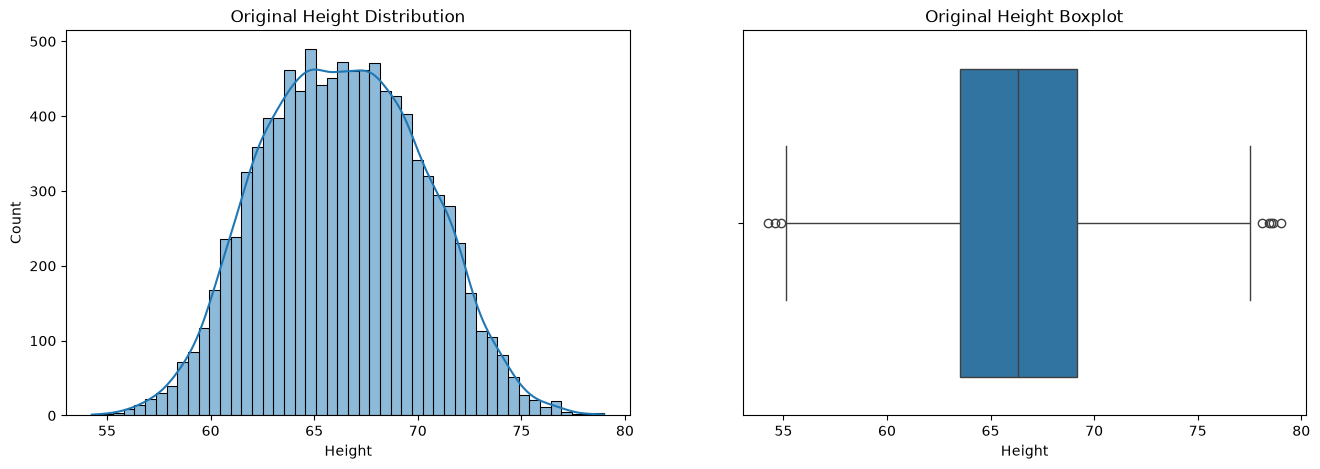

In [37]:
plt.figure(figsize=(16, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Height', kde=True)
plt.title('Original Height Distribution')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Height')
plt.title('Original Height Boxplot')

plt.show()

### **2. Calculating Percentile Boundaries**

Determine the thresholds for outliers. A common approach is capping/trimming at the **1st percentile (0.01)** and the **99th percentile (0.99)**[cite: 10].

In [39]:
# Calculate 1st and 99th percentiles
lower_limit = df['Height'].quantile(0.01)
upper_limit = df['Height'].quantile(0.99)

print("Lower Limit (1st Percentile):", lower_limit)
print("Upper Limit (99th Percentile):", upper_limit)

Lower Limit (1st Percentile): 58.13441158671655
Upper Limit (99th Percentile): 74.7857900583366


### **3. Strategy 1: Trimming**

Trimming permanently removes the outlier rows from the dataset. Always use `.copy()` to preserve the original dataframe.

In [40]:
# Apply trimming logic to a fresh copy
df_trimmed = df.copy()
df_trimmed = df_trimmed[(df_trimmed['Height'] >= lower_limit) & (df_trimmed['Height'] <= upper_limit)]

print("Trimmed shape:", df_trimmed.shape)

Trimmed shape: (9800, 3)


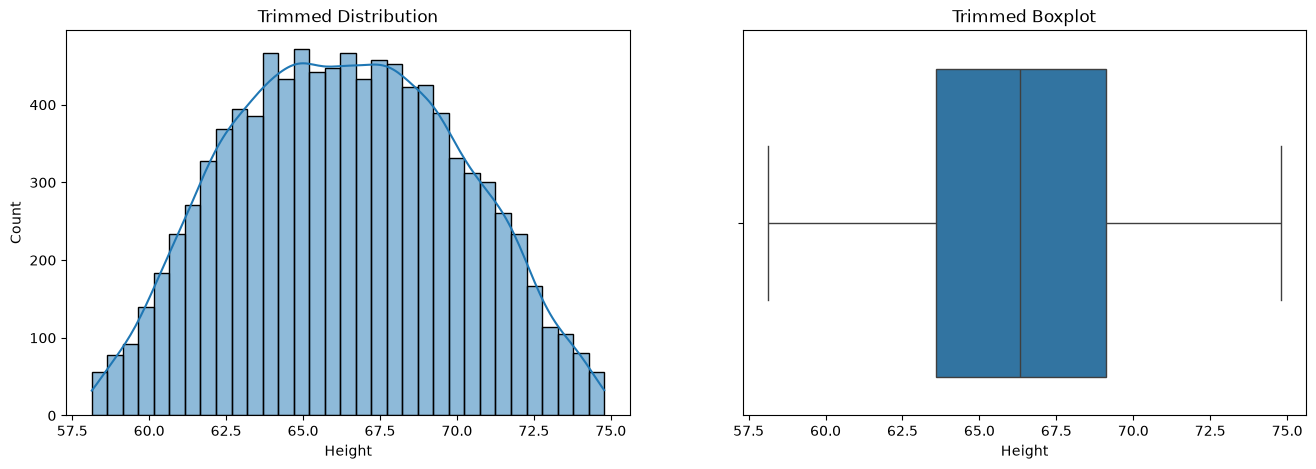

In [41]:
# Visual comparison for Trimming
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df_trimmed, x='Height', kde=True)
plt.title('Trimmed Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_trimmed, x='Height')
plt.title('Trimmed Boxplot')

plt.show()

### **4. Strategy 2: Capping (Winsorization)**

Capping modifies the values of outliers by setting them exactly to the defined percentile limits, ensuring no rows are dropped.

In [42]:
df_capped = df.copy()

# Apply nested np.where to cap values
df_capped['Height'] = np.where(
    df_capped['Height'] >= upper_limit, 
    upper_limit, 
    np.where(
        df_capped['Height'] <= lower_limit, 
        lower_limit,
        df_capped['Height']
    )
)

print("Capped shape:", df_capped.shape)

Capped shape: (10000, 3)


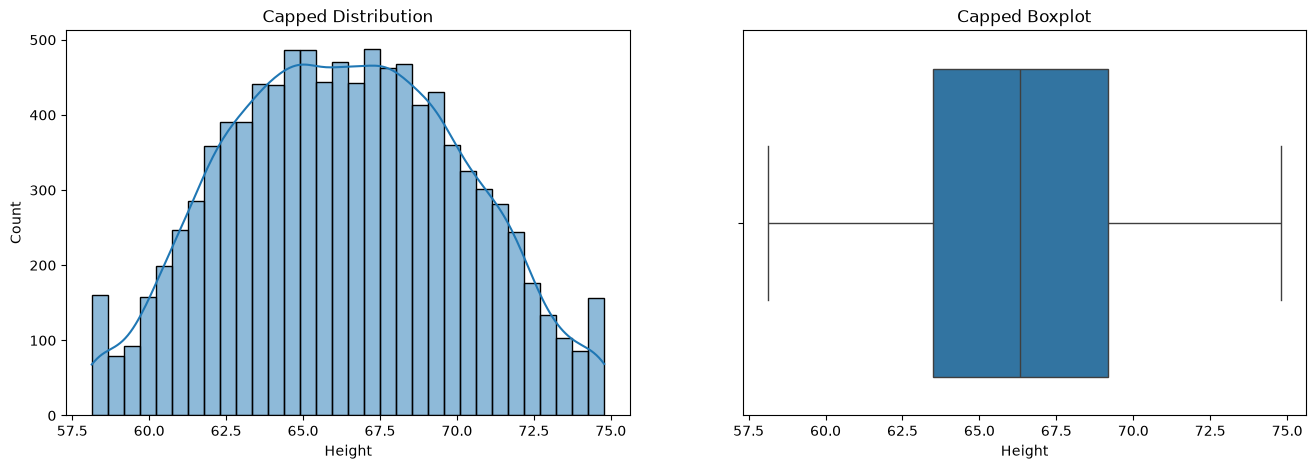

In [43]:
# Visual comparison for Capping
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df_capped, x='Height', kde=True)
plt.title('Capped Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_capped, x='Height')
plt.title('Capped Boxplot')

plt.show()

## **7. Key Revision Notes**

- **When to use the Percentile Method:** Useful when a variable doesn't perfectly follow a normal distribution, or when you specifically want to clip the extreme top and bottom percentages (e.g., top 1% and bottom 1%) regardless of statistical variance
- **Boundary Formulation:** Utilize the `.quantile()` function in Pandas.
  - Lower limit: `df['Feature'].quantile(0.01)`
  - Upper limit: `df['Feature'].quantile(0.99)`
- **Trimming:** Drops the offending rows. Best used when outliers are confirmed errors or when the dataset is large enough to absorb the loss
- **Capping (Winsorization):** Uses `np.where()` to clamp values to the maximum and minimum boundaries. Preferable when you want to retain data volume but reduce the leverage of extreme values[cite: 10].
- **Dynamic Variables:** Always pass the dynamic output of `.quantile()` to your filtering or capping logic (e.g., `upper_limit`), rather than hardcoding static numbers.